In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# Read data

In [2]:
#df = pd.read_parquet('/Users/julianeoliveira/Downloads/aesop_2025_11_10_mun_withMEM.parquet')
#df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_31_03_2026_with_MEM_all_models.parquet')

# dado com os modelos 
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_05_2026_with_MEM_all_models.parquet')

dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]


data = df.copy()


In [3]:
len(df)

788655

In [4]:
# Base variables
lst_models = [
    'sinal_ears_atend', 'sinal_evi_ivas',
    'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM',
    'EWS_COPOD', 'EWS_Rt'
]

lags = [1, 2, 3]

# Create lagged features
lagged_cols = []

for var in lst_models:
    for lag in lags:
        col_name = f"{var}_lag_{lag}"
        
        lagged_cols.append(col_name)

# Final feature list
all_features = lst_models + lagged_cols

In [5]:
data[lst_models] = data[lst_models].astype(int)

# Majority voting
threshold = round(len(lst_models) / 2,0)

lst_cities = []

for code in data.co_ibge.unique():
    print(f"Processing {code}...")

    set_muni = data[data.co_ibge == code].sort_values(['year_week'])
    
    set_muni['hard_voting_ivas'] = (set_muni[lst_models]
                                .sum(axis=1) >= threshold
                                ).astype(int)
    
    lst_cities.append(set_muni)

data = pd.concat(lst_cities)

Processing 110001...
Processing 110002...
Processing 110005...
Processing 110007...
Processing 110008...
Processing 110009...
Processing 110010...
Processing 110011...
Processing 110013...
Processing 110014...
Processing 110015...
Processing 110018...
Processing 110020...
Processing 110025...
Processing 110026...
Processing 110028...
Processing 110029...
Processing 110030...
Processing 110032...
Processing 110033...
Processing 110034...
Processing 110037...
Processing 110040...
Processing 110045...
Processing 110050...
Processing 110060...
Processing 110080...
Processing 110090...
Processing 110092...
Processing 110094...
Processing 110100...
Processing 110110...
Processing 110120...
Processing 110130...
Processing 110143...
Processing 110145...
Processing 110146...
Processing 110147...
Processing 110148...
Processing 110149...
Processing 110150...
Processing 110155...
Processing 110160...
Processing 110170...
Processing 110180...
Processing 120005...
Processing 120010...
Processing 12

In [6]:
data.warning_final_mem_surge_01.sum()

26411

In [7]:
data.hard_voting_ivas.sum()

122353

In [8]:
data[lst_models].sum()

sinal_ears_atend    183669
sinal_evi_ivas      150528
EWS_ISF             103794
EWS_LOF             124283
EWS_OCSVM           110830
EWS_COPOD           105233
EWS_Rt              129921
dtype: int64

In [9]:
data.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'hard_voting_ivas'],
      dtype='object')

In [10]:
lst = []

for code in data.co_ibge.unique():
    print(f"Processing {code}...")

    set_muni = data[data.co_ibge == code].sort_values(['year_week'])

    # --- create lagged features ---
    for var in lst_models:
       for lag in [1, 2, 3]:
            set_muni[f"{var}_lag_{lag}"] = set_muni[var].shift(lag).fillna(0).astype(int)
            

    # --- train only if surges exist with >1 class ---
    if set_muni["warning_final_mem_surge_01"].sum() > 1:
        X = set_muni[all_features].fillna(0) #.

        y = set_muni['mem_surge_01_correct_with_consec']#['warning_final_mem_surge_01']

        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=500, stratify=y
        )

        # fit model
        clf = LogisticRegression(class_weight="balanced", max_iter=500)
        clf.fit(X_train, y_train)

        # predicted probabilities + ensemble signal
        set_muni["risk_probs"] = clf.predict_proba(X)[:, 1]
        set_muni["sinal_ens_ivas_new"] = (set_muni["risk_probs"] > 0.5).astype(int)

    else:
        # fallback: keep old ensemble signal
        set_muni["sinal_ens_ivas_new"] = set_muni["hard_voting_ivas"]

    lst.append(set_muni)


Processing 110001...
Processing 110002...
Processing 110005...
Processing 110007...
Processing 110008...
Processing 110009...
Processing 110010...
Processing 110011...
Processing 110013...
Processing 110014...
Processing 110015...
Processing 110018...
Processing 110020...
Processing 110025...
Processing 110026...
Processing 110028...
Processing 110029...
Processing 110030...
Processing 110032...
Processing 110033...
Processing 110034...
Processing 110037...
Processing 110040...
Processing 110045...
Processing 110050...
Processing 110060...
Processing 110080...
Processing 110090...
Processing 110092...
Processing 110094...
Processing 110100...
Processing 110110...
Processing 110120...
Processing 110130...
Processing 110143...
Processing 110145...
Processing 110146...
Processing 110147...
Processing 110148...
Processing 110149...
Processing 110150...
Processing 110155...
Processing 110160...
Processing 110170...
Processing 110180...
Processing 120005...
Processing 120010...
Processing 12

Processing 430880...
Processing 430885...
Processing 430890...
Processing 430900...
Processing 430905...
Processing 430910...
Processing 430912...
Processing 430915...
Processing 430920...
Processing 430925...
Processing 430930...
Processing 430940...
Processing 430950...
Processing 430955...
Processing 430957...
Processing 430960...
Processing 430965...
Processing 430970...
Processing 430975...
Processing 430980...
Processing 430990...
Processing 430995...
Processing 431000...
Processing 431010...
Processing 431020...
Processing 431030...
Processing 431033...
Processing 431036...
Processing 431040...
Processing 431041...
Processing 431043...
Processing 431046...
Processing 431050...
Processing 431053...
Processing 431055...
Processing 431057...
Processing 431060...
Processing 431065...
Processing 431070...
Processing 431075...
Processing 431080...
Processing 431085...
Processing 431087...
Processing 431090...
Processing 431100...
Processing 431110...
Processing 431112...
Processing 43

Processing 510050...
Processing 510060...
Processing 510080...
Processing 510100...
Processing 510120...
Processing 510125...
Processing 510130...
Processing 510140...
Processing 510160...
Processing 510170...
Processing 510180...
Processing 510185...
Processing 510190...
Processing 510250...
Processing 510260...
Processing 510263...
Processing 510267...
Processing 510268...
Processing 510269...
Processing 510270...
Processing 510279...
Processing 510285...
Processing 510300...
Processing 510305...
Processing 510310...
Processing 510320...
Processing 510325...
Processing 510330...
Processing 510335...
Processing 510336...
Processing 510337...
Processing 510340...
Processing 510343...
Processing 510345...
Processing 510350...
Processing 510360...
Processing 510370...
Processing 510380...
Processing 510385...
Processing 510390...
Processing 510395...
Processing 510410...
Processing 510420...
Processing 510450...
Processing 510452...
Processing 510454...
Processing 510455...
Processing 51

# Save data

In [11]:
final_res = pd.concat(lst)

In [12]:
final_res.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'hard_voting_ivas', 'sinal_ears_atend_lag_1', 'sinal_ears_atend_lag_2',
       'sinal_ears_atend_lag_3', 'sinal_evi_ivas_lag_1',
       'sinal_evi_ivas_lag_2', 'sinal_evi_ivas_lag_3', 'EWS_ISF_lag_1',
       'EWS_ISF_lag_2', 'EWS_ISF_lag_3', 'EWS_LOF_lag_1', 'EWS_LOF_lag_2',
       'EWS_LOF_lag_3', 'EWS_OCSVM_lag_1', 'EWS_OCSVM_lag_2',
       'EWS_OCSVM_lag_3', 'EWS_COPOD_lag_1', 'EWS_COPOD_lag_2',
       'EWS_COPOD_lag_3', 'EWS_Rt_lag_1', 'EWS_Rt_lag_2', 'EWS_Rt_lag_3',
       'risk_probs', 'sinal_ens_ivas_new'],
      dtype='object')

In [14]:
from pathlib import Path
from datetime import datetime

out_dir = Path("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling")

fname = f"aesop_{datetime.now():%d_%m_%Y}_with_MEM_all_mods_ens.parquet"

final_res.to_parquet(out_dir / fname)

# Plot to check

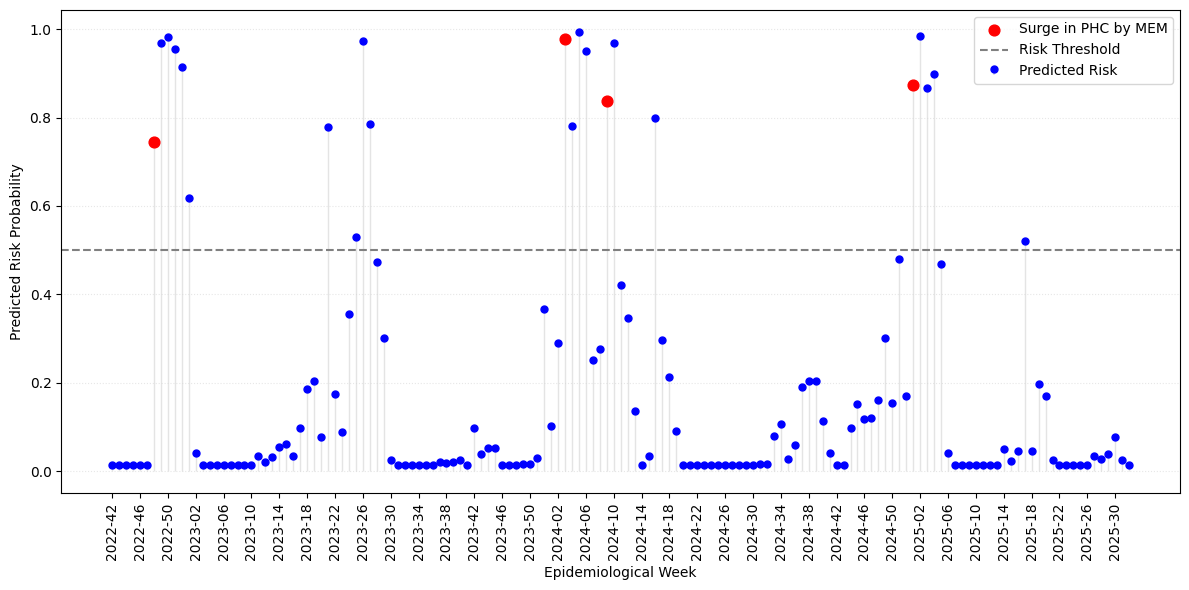

In [15]:
dta_plot = lst[2]

plt.figure(figsize=(12, 6))

# Stem plot for predicted risk
(markerline, stemlines, baseline) = plt.stem(
    dta_plot['year_week'], dta_plot['risk_probs'],
    basefmt=" ", linefmt='lightgray', markerfmt='o', label='Predicted Risk'
)
plt.setp(stemlines, linewidth=1, alpha=0.6)
plt.setp(markerline, markersize=5, markerfacecolor='blue', markeredgecolor='blue')

# Highlight surges (mem_surge_01 == 1)
plt.scatter(
    dta_plot.loc[dta_plot['warning_final_mem_surge_01'] == 1, 'year_week'],
    dta_plot.loc[dta_plot['warning_final_mem_surge_01'] == 1, 'risk_probs'],
    color='red', s=60, label='Surge in PHC by MEM', zorder=3
)

# Add threshold line
plt.axhline(0.5, color='gray', linestyle='--', label='Risk Threshold')

# X-axis ticks (every 4 weeks to reduce clutter)
plt.xticks(dta_plot["year_week"][::4], rotation=90)

# Labels & formatting
plt.xlabel('Epidemiological Week')
plt.ylabel('Predicted Risk Probability')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.show()


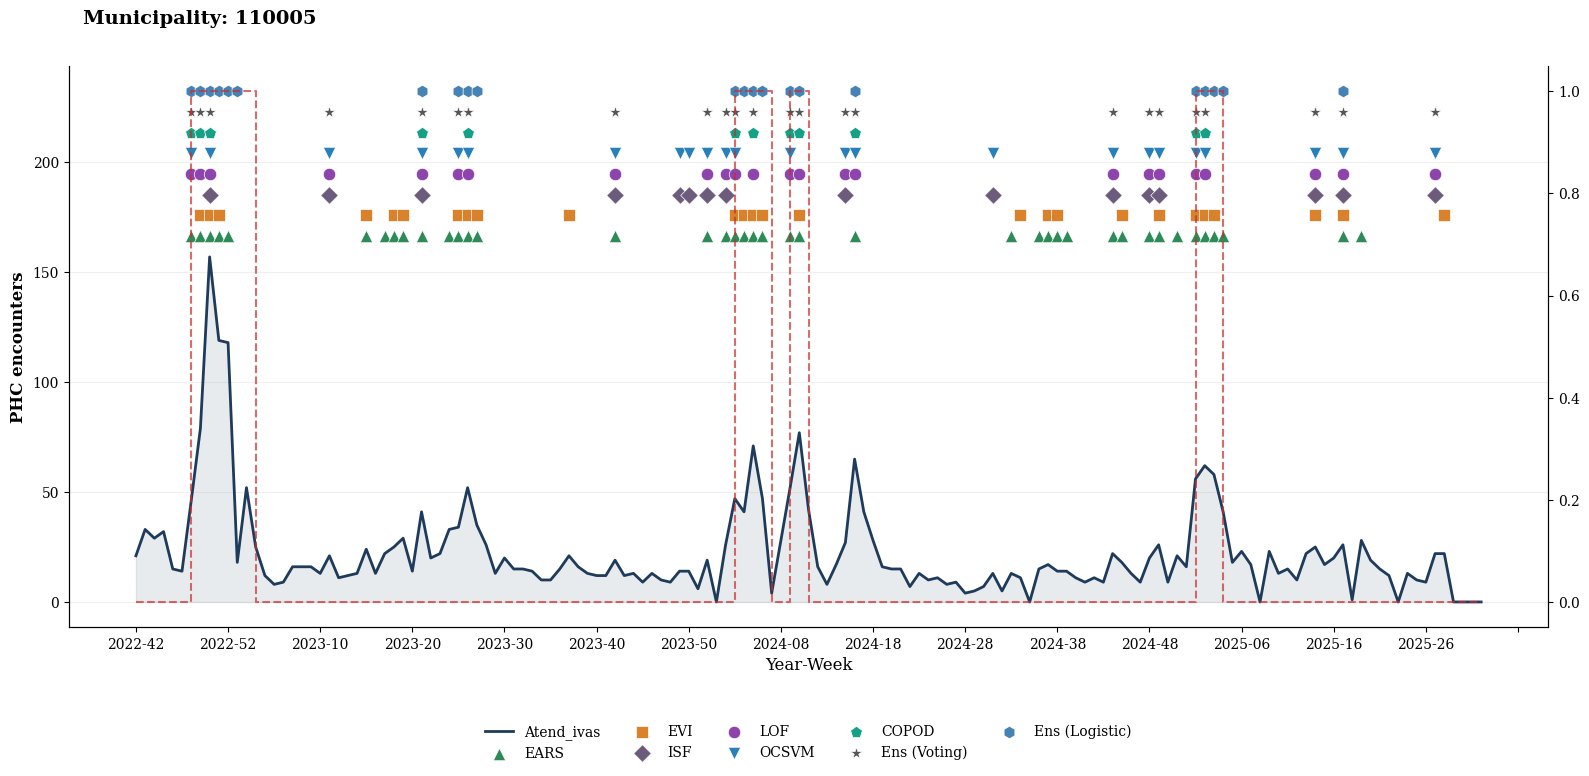

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style context
#plt.rcParams['font.sans-serif'] = "Arial"
#plt.rcParams['font.family'] = "sans-serif"

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

muni = dta_plot.co_ibge.unique()[0]
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Color Palette (Lancet-inspired) ---
# 1. Expanded Lancet Color Palette
colors = {
    "main": "#1f3b5c",       # Deep navy (Trend line)
    "secondary": "#c52e2e",  # Muted crimson (MEM surges)
    "ears": "#2e8b57",       # Sea green
    "evi": "#d9822b",        # Ochre/Amber
    "vot": "#555555",        # Slate grey (Voting)
    "LR": "#4682B4",         # Steel blue (Logistic)
    # New distinct colors for the EWS models:
    "isf": "#6c5b7b",        # Muted purple
    "lof": "#8e44ad",        # Amethyst
    "ocsvm": "#2980b9",      # Belize blue
    "copod": "#16a085",      # Nephrite green
   # "FFA": "#e76f51"
}


# 1. Primary Plot: Atend_ivas
ax1.plot(dta_plot["year_week"], dta_plot["atend_ivas"], 
         color=colors["main"], linewidth=2, label="Atend_ivas", zorder=2)
ax1.fill_between(dta_plot["year_week"], dta_plot["atend_ivas"], 
                 color=colors["main"], alpha=0.1)

# 2. Binary Signal Strip (Warnings)
# Instead of scaling by max(), we create a logical offset
y_max = dta_plot["atend_ivas"].max()
offset = y_max * 0.06

# Grouped scatter plots for signals
signals = [
    ("sinal_ears_atend",   colors["ears"],  "^", "EARS"),
    ("sinal_evi_ivas",     colors["evi"],   "s", "EVI"),
    ("EWS_ISF",            colors["isf"],   "D", "ISF"),
    ("EWS_LOF",            colors["lof"],   "o", "LOF"),
    ("EWS_OCSVM",          colors["ocsvm"], "v", "OCSVM"),
    ("EWS_COPOD",          colors["copod"], "p", "COPOD"),
    #("warning_ivas_ffa",   colors["FFA"],    "h", "FFA"),
    ("hard_voting_ivas",   colors["vot"],   "*", "Ens (Voting)"),
    ("sinal_ens_ivas_new", colors["LR"],    "h", "Ens (Logistic)"),
]


for i, (col, color, marker, lbl) in enumerate(signals):
    mask = dta_plot[col] == 1
    ax1.scatter(dta_plot.loc[mask, "year_week"], 
                [y_max + (i+1)*offset] * mask.sum(), 
                marker=marker, color=color, s=80, label=lbl, 
                edgecolors='white', linewidth=0.5, zorder=4)

# 4. Secondary Axis & GRID
ax2 = ax1.twinx()
ax2.step(dta_plot["year_week"], dta_plot["mem_surge_01_correct_with_consec"], 
         where='post', color=colors["secondary"], linestyle="--", alpha=0.7)

# 4. Axes Aesthetics
ax1.set_ylabel("PHC encounters", fontweight='bold', fontsize=12)
ax1.set_xlabel("Year-Week", fontsize=12)

# Remove top/right spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Grid - only horizontal for readability
ax1.yaxis.grid(True, linestyle='-', alpha=0.2)
ax1.xaxis.set_major_locator(plt.MaxNLocator(20)) # Automatically reduces clutter

# 5. Legend and Labeling
ax1.text(0.01, 1.1, f"Municipality: {muni}", transform=ax1.transAxes, 
         fontsize=14, fontweight='bold', va='top')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc="upper center", bbox_to_anchor=(0.5, -0.15), 
           ncol=5, frameon=False, fontsize=10)

# Apply to the primary y-axis (Atend_ivas)
#ax1.yaxis.grid(True, linestyle='-', color='#cccccc', alpha=0.3, zorder=1)

# Ensure vertical lines are OFF to reduce clutter
#ax1.xaxis.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()